# Words Clustering

In [1]:
# in word clustering and grouping words by topic the first step that we have to do is to clean our text:
# text have stopwords like 'is', 'the' and ... also texts may have special characters and we have to make sure that our text
# is in lower case, then we need to tokenize our text: change it from "Hello world" to ["Hello", "world"]

In [2]:
#importing necessaries libraries
import re
import string
from nltk.corpus import stopwords
from nltk import word_tokenize, pos_tag
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import glob
from pathlib import Path
import numpy as np
import pandas as pd

In [3]:
# Download resources
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/armitasabri/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/armitasabri/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/armitasabri/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/armitasabri/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/armitasabri/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
# Get the data
#create empty dataframe
df = pd.DataFrame(columns=['docid','text'])

# get all files ending with .txt
docs = [x for x in glob.glob("*.txt")]

#fill dataframe
for doc in docs:
    txt = Path(doc).read_text()
    #df.loc[len(df.index)] adds new row in every iteration
    # the doc[:-4] is going to get the document id without .txt extension
    df.loc[len(df.index)] = [doc[:-4], txt]

#set index docid       
df = df.set_index('docid')

In [5]:
# Initialize stemmer and stop words
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))
# stemmer is a tool in Natural Language Processing (NLP) that changes the word to it's stem: like running will be changed to run
# Stemming is the process of removing prefixes or suffixes from words to produce their base form, 
# which may not always be a valid word in the dictionary like studies will be changed to studi.
# we use stemmer to normalize our words and reduce vocabulary size because 
# By grouping similar words together, stemming makes the text more manageable for machine learning models.

In [6]:
# using Stemmer or Lemmatization:
# while stemmer is faster than lemmatization it has less word accuracy and it's good enough for short texts but Lemmatization
# is computationally expensive but in domain-specific vocabulary lemmatization will do a better job so I decided to go with
# lemmatization instead of stemmer.

In [7]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

In [8]:
# what is POS tags and what is WordNet tags:
# POS (Part-of-Speech) tags are labels assigned to words in a sentence that indicate their grammatical role, such as:
# Nouns (NN, NNS, etc.): Person, place, thing (e.g., "dog", "cars").
# Verbs (VB, VBD, etc.): Actions or states (e.g., "run", "is").
# Adjectives (JJ, JJR, etc.): Descriptive words (e.g., "big", "better").
# Adverbs (RB, RBR, etc.): Words modifying verbs, adjectives, or other adverbs (e.g., "quickly").

# WordNet is a lexical database in Python that provides information about words, their meanings, and relationships. 
# It supports lemmatization, but to use it, we need to specify the Part-of-Speech (POS) tag of each word.
# WordNet uses simpler POS tags:
# 'n': Noun
# 'v': Verb
# 'a': Adjective
# 'r': Adverb
#The WordNetLemmatizer in NLTK requires WordNet-style tags to correctly lemmatize a word. 
#If we pass it a word without specifying its POS tag, it will default to treating the word as a noun, 
#which can lead to incorrect lemmatization.
# like 
# word = "running"
# print(lemmatizer.lemmatize(word))  # Default POS is 'n': Output -> "running"
# print(lemmatizer.lemmatize(word, pos='v'))  # Correct POS: Output -> "run"
# so if we call lemmatize method and give the pos attribute we will get a more accurate answer.

In [9]:
# Function to map POS tags to WordNet tags
# if we were to consider all words including verbs and adverbs
# def get_wordnet_pos(tag):
#     if tag.startswith('J'):
#         return 'a'  # Adjective
#     elif tag.startswith('V'):
#         return 'v'  # Verb
#     elif tag.startswith('N'):
#         return 'n'  # Noun
#     elif tag.startswith('R'):
#         return 'r'  # Adverb
#     else:
#         return 'n'  # Default to noun

In [10]:
# Function to map POS tags to WordNet tags
# the provided notebook (PA_Clustering_words) only considered nouns, to improve the analysis I included adjectives too
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'  # Adjective
    elif tag.startswith('N'):
        return 'n'  # Noun
    else:
        return None  # Ignore other parts of speech

In [11]:
# simple example to fully demonstrate get_wordnet_pos() and pos_tag(tokens) in preprocess_text_with_lemmatization()
text = "patients cough heavily"
tokens = word_tokenize(text)
print(tokens) 

['patients', 'cough', 'heavily']


In [12]:
# POS Taging
from nltk import pos_tag

pos_tags = pos_tag(tokens)
print(pos_tags)

[('patients', 'NNS'), ('cough', 'VBP'), ('heavily', 'RB')]


In [13]:
# the preprocess_text is like the 'PA_Clustering_words' preprocess method but when I tokenize the text I saw some unsual character 
# among the list like '×' and \u200b so I tried to specifically removes those too

In [14]:
#after applying NMF and seeing top topics I saw words like age, day and year are showing and as they don't add any information for clinical
# diagnosis I want to remove them in preprocessing stage
# Load stopwords
stop_words = set(stopwords.words('english'))

# Add "age," "day," and "year" to stop words
custom_stop_words = {"age", "day", "year"}
stop_words.update(custom_stop_words)

In [15]:
def preprocess_text(text):
    """Clean text and lemmatize only nouns and adjectives."""
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\[.*?\]', '', text)  # Remove text in brackets
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # Remove punctuation
    text = re.sub(r'×', ' ', text) # Remove × special charachter
    text = re.sub(r'\u200b', ' ', text)  # Remove zero-width spaces
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces and strip leading/trailing spaces
    text = re.sub(r'\w*\d\w*', '', text)  # Remove words containing numbers
    tokens = word_tokenize(text)  # Tokenize the text
    lemmatized_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tag(tokens)
        if word not in stop_words and get_wordnet_pos(pos)  # Only nouns and adjectives
    ]
    # Remove custom stop words
    filtered_tokens = [word for word in lemmatized_tokens if word not in stop_words]

    return " ".join(filtered_tokens)

In [16]:
# Apply lemmatization to the dataset
df['cleaned_text'] = df['text'].apply(preprocess_text)
df.head()

,text,cleaned_text
docid,,
19860925,Our 24-year-old non-smoking male patient prese...,male patient repeated hemoptysis concomitant r...
26228535,A 25-year-old female patient had noticed left-...,female patient visual loss amenorrhea right he...
27773410,A 69-year-old male diabetic patient was admitt...,male diabetic patient acute ventricular lv fai...
28103924,Our patient was a 7-year-old Italian boy born ...,patient italian boy uneventful gestation norma...
27064109,A 53-year-old man came to our hospital with si...,man hospital sign symptom acute heart failure ...


In [17]:
df.to_csv('document_df.csv', index=False)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    stop_words='english',        # Built-in English stop words
    ngram_range=(1, 2),          # Include unigrams and bigrams
    max_df=0.85,                 # Ignore terms in more than 85% of documents
    min_df=0.05                  # Ignore terms in fewer than 5% of documents
)
# min_df and max_df both increased to see the effect of it on vectorizer
# if we choose ngram_range=(1, 2) we will have 619 columns and if we choose ngram_range=(1, 1) we will have 594 columns
# but I decided to go with (1,2) and include bigrams because in this case for input like "Patients experience chronic cough"
# for unigram we will have ["patients", "experience", "chronic", "cough"] but for bigram we will have 
# ["patients experience", "experience chronic", "chronic cough"] and for example we can get more information from "chronic cough" than
# "chronic", "cough"
# fit and transform the cleaned text into a Document-Term Matrix
dtm = vectorizer.fit_transform(df['cleaned_text'])

# Convert to a DataFrame for better interpretability
dtm_df = pd.DataFrame(
    dtm.toarray(), 
    columns=vectorizer.get_feature_names_out(), 
    index=df.index
)
dtm_df.head()

,abdomen,abdominal,abdominal pain,abdominal ultrasound,abnormal,abnormality,absence,acid,activity,acute,...,wall,weakness,week,weight,weight loss,white,white blood,woman,workup,xray
docid,,,,,,,,,,,,,,,,,,,,,
19860925,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.10475,0.0,0.0,0.0,0.0,0.000000,0.000000
26228535,0.000000,0.0,0.0,0.0,0.0,0.0,0.073781,0.064760,0.000000,0.000000,...,0.055614,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000
27773410,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.131220,...,0.061777,0.0,0.046639,0.00000,0.0,0.0,0.0,0.0,0.090172,0.000000
28103924,0.068498,0.0,0.0,0.0,0.0,0.0,0.000000,0.075895,0.273893,0.000000,...,0.000000,0.0,0.246026,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000
27064109,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.060331,...,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.000000,0.068808


### Apply NMF for Topic Modeling

In [19]:
from sklearn.decomposition import NMF

# Set the number of topics
num_topics = 5

# Apply NMF
nmf_model = NMF(n_components=num_topics, random_state=42)
doc_topic_matrix = nmf_model.fit_transform(dtm)  # Document-topic matrix :W
topic_term_matrix = nmf_model.components_  # Topic-term matrix :H
# V = W * H
# Function to display topics
def display_topics(model, feature_names, num_top_words=10):
    """Print top words for each topic."""
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic #{topic_idx + 1}:")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]))

# Display topics
display_topics(nmf_model, vectorizer.get_feature_names_out())



Topic #1:
blood, count, negative, chest, platelet, hospital, therapy, culture, lung, mg

Topic #2:
tumor, mass, cell, cm, lesion, figure, lymph, node, lymph node, metastasis

Topic #3:
mitral, pulmonary, valve, artery, echocardiography, heart, coronary, atrial, cardiac, ventricular

Topic #4:
normal, level, range, normal range, ul, serum, function, acid, blood, renal

Topic #5:
right, left, eye, lesion, normal, arm, month, mri, nerve, artery


In [20]:
# Create a DataFrame from the Document-Topic Matrix
doc_topic_df = pd.DataFrame(doc_topic_matrix, index=df.index)

# Rename columns to start from 1  --- if we don't do that we see 0 1 2 3 4 instead of topic 1  topic 2 ...
doc_topic_df.columns = [f"Topic {i+1}" for i in range(doc_topic_df.shape[1])]

doc_topic_df.head()

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
docid,,,,,
19860925,0.017508,0.264195,0.029544,0.000000,0.062822
26228535,0.000000,0.265490,0.000000,0.083178,0.000000
27773410,0.026613,0.000000,0.265162,0.034202,0.072384
28103924,0.085162,0.000000,0.000000,0.128469,0.157184
27064109,0.068863,0.017117,0.260143,0.092252,0.008487


In [21]:
# so document with id 19860925 is mostly about topic 2 (topic 1 is we counting from 0)

In [22]:
# Assign dominant topic to each document
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1)+1
print(df[['text', 'dominant_topic']].head())

                                                       text  dominant_topic
docid                                                                      
19860925  Our 24-year-old non-smoking male patient prese...               2
26228535  A 25-year-old female patient had noticed left-...               2
27773410  A 69-year-old male diabetic patient was admitt...               3
28103924  Our patient was a 7-year-old Italian boy born ...               5
27064109  A 53-year-old man came to our hospital with si...               3


In [23]:
set(df['dominant_topic'])

{1, 2, 3, 4, 5}

### Visualization

/var/folders/rs/mjwx2jg51950x4tmt93fhrrc0000gn/T/ipykernel_28836/3243016558.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index+1, y=topic_counts.values, palette='viridis')


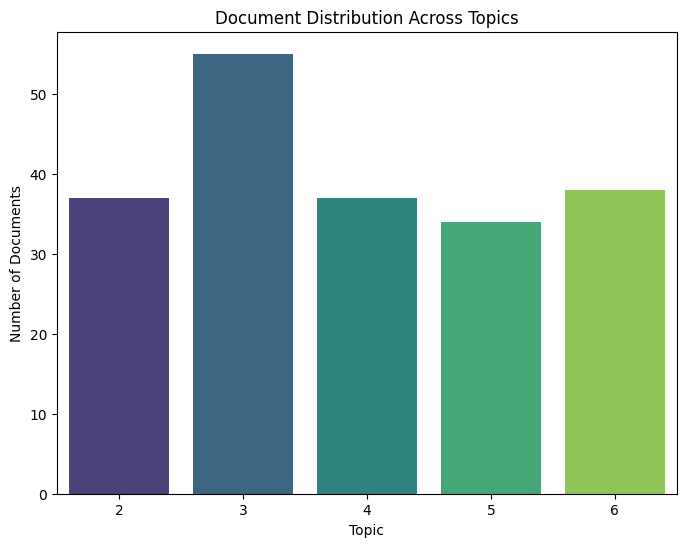

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of documents in each topic
topic_counts = df['dominant_topic'].value_counts()

# Plot topic distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=topic_counts.index+1, y=topic_counts.values, palette='viridis')
plt.title('Document Distribution Across Topics')
plt.xlabel('Topic')
plt.ylabel('Number of Documents')
plt.show()

In [25]:
# we can see among 200 text files the topic 2 which is Topic #2:
# tumor, mass, cell, cm, lesion, figure, lymph, node, lymph node, resection
# repeat has the most majority and maybe we can come to this conclusion that most of the papers are discussing lymph node cancer

In [26]:
# Visualize top words in each topic
for topic_idx, topic in enumerate(topic_term_matrix):
    top_words = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")


Topic 1: blood, count, negative, chest, platelet, hospital, therapy, culture, lung, mg
Topic 2: tumor, mass, cell, cm, lesion, figure, lymph, node, lymph node, metastasis
Topic 3: mitral, pulmonary, valve, artery, echocardiography, heart, coronary, atrial, cardiac, ventricular
Topic 4: normal, level, range, normal range, ul, serum, function, acid, blood, renal
Topic 5: right, left, eye, lesion, normal, arm, month, mri, nerve, artery


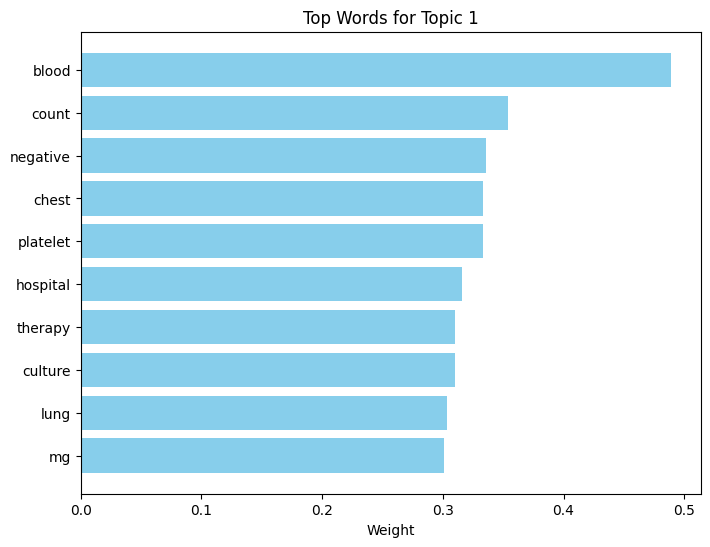

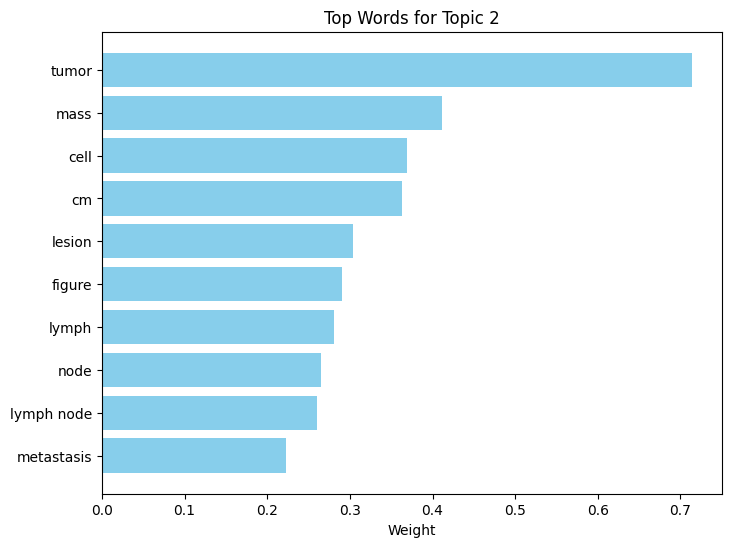

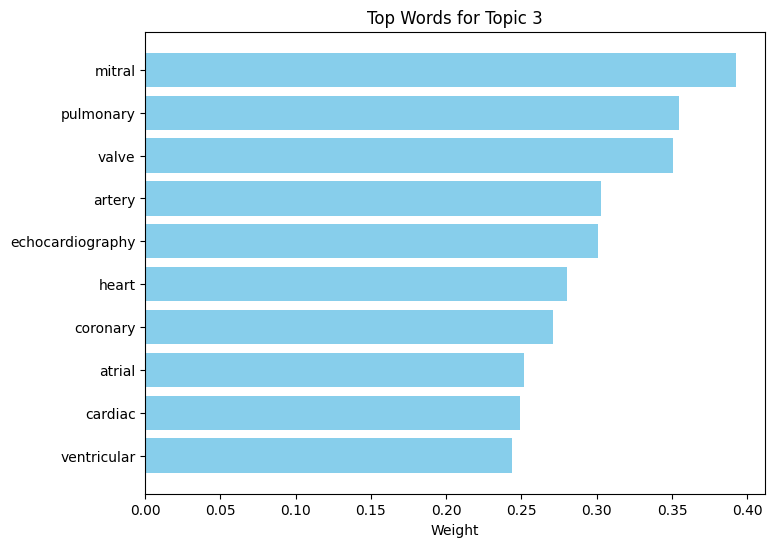

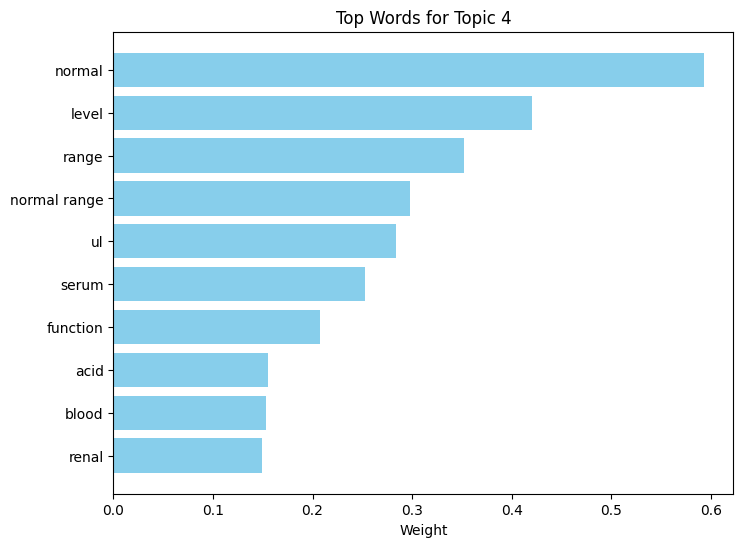

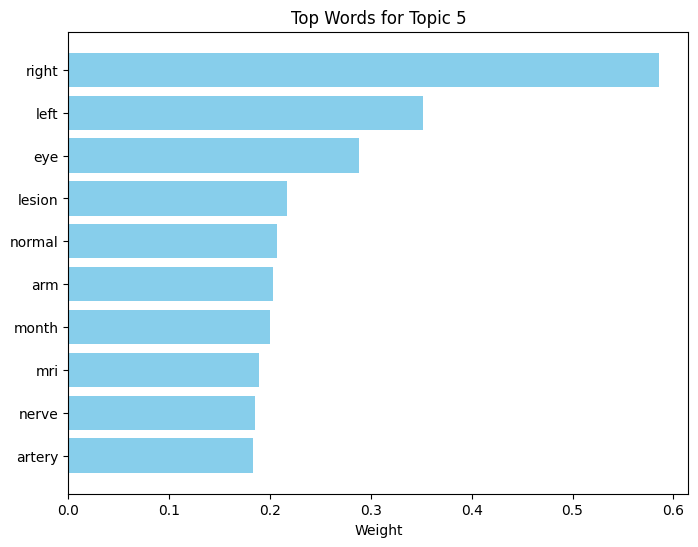

In [27]:
# Visualize top words in each topic
def plot_top_words(model, feature_names, num_top_words=10):
    """Plot the top words for each topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]
        top_weights = topic[topic.argsort()[:-num_top_words - 1:-1]]

        plt.figure(figsize=(8, 6))
        plt.barh(top_words, top_weights, color='skyblue')
        plt.xlabel('Weight')
        plt.title(f"Top Words for Topic {topic_idx + 1}")
        plt.gca().invert_yaxis()  # Invert y-axis for better readability
        plt.show()

# Call the function to plot top words
plot_top_words(nmf_model, vectorizer.get_feature_names_out())


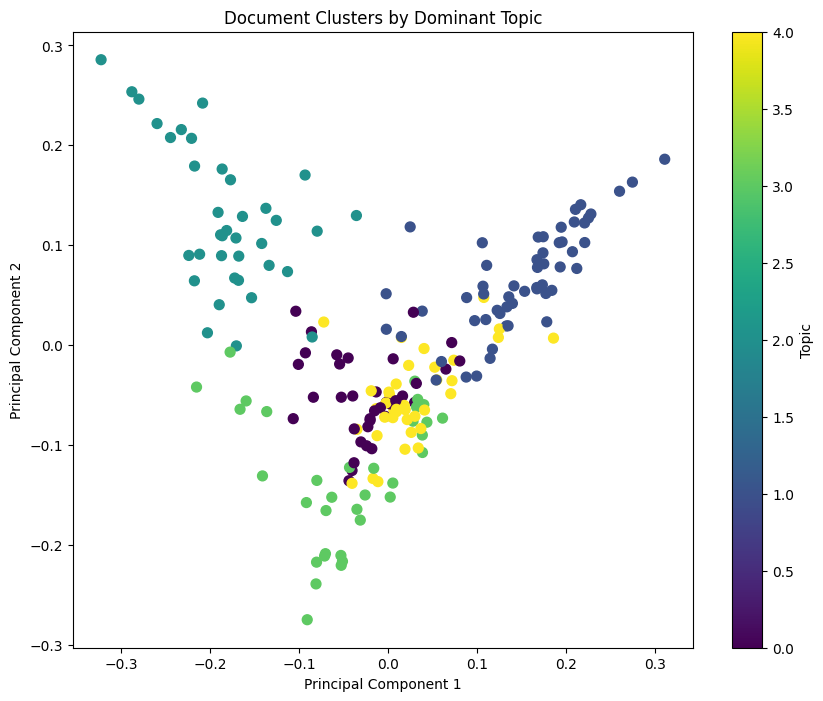

In [28]:
from sklearn.decomposition import PCA
dominant_topics = np.argmax(doc_topic_matrix, axis=1)
# Reduce dimensionality of the Document-Topic Matrix
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(doc_topic_matrix)

# Plot documents in 2D space
plt.figure(figsize=(10, 8))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=dominant_topics, cmap='viridis', s=50)
plt.colorbar(label="Topic")
plt.title("Document Clusters by Dominant Topic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [29]:
# above image can help us to understand various things:
# each point in the above image is a document and the colors indicate the dominant topic assigned to each document.
# Documents with the same color are grouped together because they share a similar topic.
# Overlapping areas suggest that documents in these regions might share common terms or themes,
# making them harder to distinguish completely.
#for clusters that are clearly separated we can say that topics are well-defined and distinct like topic 1 and 3 and 1 and 2

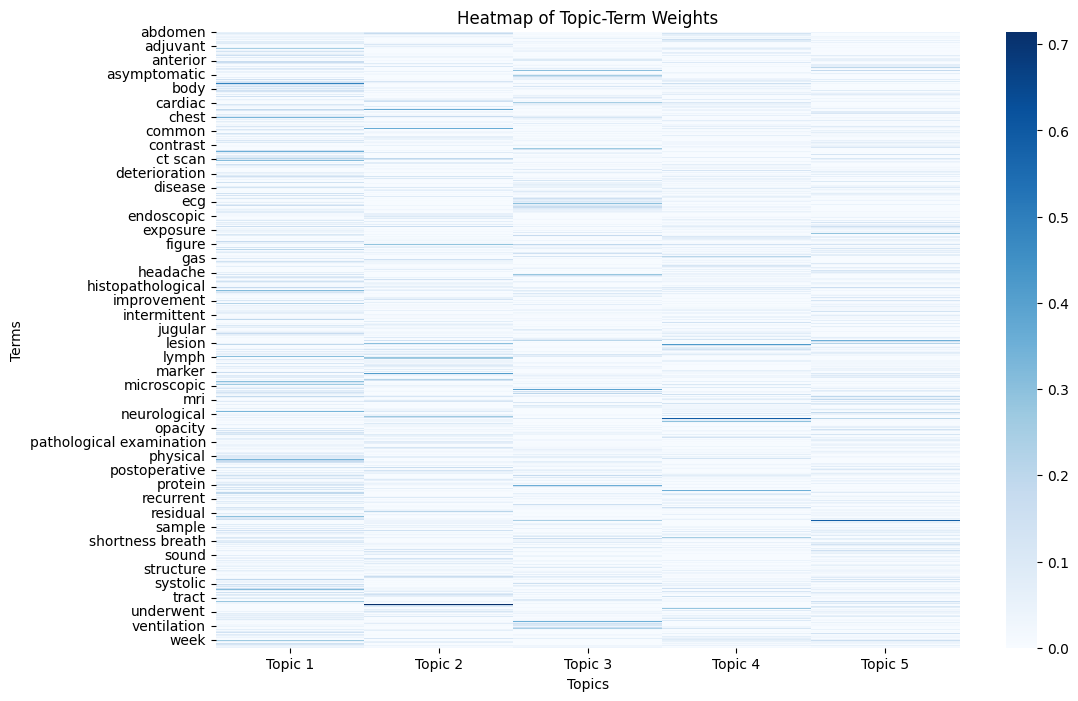

In [30]:
import seaborn as sns

# Create a DataFrame for the topic-term matrix
topic_term_df = pd.DataFrame(nmf_model.components_, 
                             columns=vectorizer.get_feature_names_out(), 
                             index=[f"Topic {i+1}" for i in range(num_topics)])

# Plot a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(topic_term_df.T, cmap="Blues", annot=False, cbar=True)
plt.title("Heatmap of Topic-Term Weights")
plt.xlabel("Topics")
plt.ylabel("Terms")
plt.show()

## Are there any other weighting solutions next to TF-IDF?

yes there are several weighting schemes besides TF-IDF for constructing a Document-Term Matrix (DTM). 
Each scheme has its own strengths and is suitable for specific types of text analysis:

### Raw Term Frequency (TF)
Simply counts how many times a term appears in a document.<br>

"+":
Simple to compute.
Works well when all terms are equally important.<br>
"-":
Does not account for the importance of terms in the corpus (e.g., common words like "patient").<br>

Example:

Document: "cough cough chronic patient"

Term: "cough"

Weight: 2 (appears twice)


### Binary Term Frequency
Indicates whether a term is present in a document (1) or not (0).<br>
"+":
Ignores term frequency, focusing only on the presence of terms.
Useful for very sparse datasets.<br>
"-":
Loses information about term frequency, which may be important for certain analyses.

### Augmented Term Frequency
Scales the term frequency to account for the maximum frequency of any term in the document:

$$
\text{Augmented TF}(t, d) = 0.5 + 0.5 \cdot \frac{\text{TF}(t, d)}{\max(\text{TF}(t', d)) \text{ for all } t'}
$$

Where:
- \( t \): Term
- \( d \): Document
- TF(t, d): Term Frequency of \( t \) in document \( d \)
- max(TF)(t', d): Maximum Term Frequency of any term \( t' \) in document \( d \)

  
"+":
Reduces the bias of frequent terms dominating the matrix.<br>
"-":
Slightly more complex than raw term frequency.

### BM25 Weighting
A probabilistic ranking function widely used in information retrieval (e.g., search engines). BM25 adjusts term frequency based on document length and term rarity.<br>
"+":
Incorporates document length normalization.
Performs well in ranking tasks.<br>
"-":
More complex to compute compared to TF-IDF.

### Logarithmic Term Frequency (TF)

Scales term frequency logarithmically to dampen the effect of very frequent terms:

$$
\text{Log TF}(t, d) = 
\begin{cases} 
1 + \log(\text{TF}(t, d)), & \text{if } \text{TF}(t, d) > 0 \\
0, & \text{if } \text{TF}(t, d) = 0
\end{cases}
$$

"+": Handles cases where some terms dominate by frequency.  
"-": Still sensitive to very rare terms.


### Term Frequency-Probabilistic Inverse Document Frequency (TF-PIDF)
Similar to TF-IDF but uses a probabilistic approach for computing term rarity.<br>
"+":
Can perform better in specific cases where term rarity follows a probabilistic distribution.<br>
"-":
Less commonly used compared to TF-IDF.

### Word Embeddings
Represents words as dense numerical vectors in a continuous vector space using models like Word2Vec, GloVe, or FastText.<br>
"+":
Captures semantic similarity (e.g., "doctor" and "physician" are close in vector space).
Encodes rich contextual information.<br>
"-":
Requires pre-trained models or large corpora to train effectively.
Produces dense, high-dimensional matrices.

### Latent Semantic Indexing (LSI) Weighting
Reduces dimensionality of the DTM by using Singular Value Decomposition (SVD) to find latent semantic structures in the data.<br>
"+":
Captures relationships between terms that co-occur in similar contexts.
Useful for topic modeling and document similarity.<br>
"-":
Computationally expensive for large datasets.

In [31]:
# alternative to TF-IDF :Using augmented term frequency
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')  # Unigrams only
raw_dtm = vectorizer.fit_transform(df['cleaned_text'])  # Cleaned text data
term_names = vectorizer.get_feature_names_out()  # List of terms

def compute_augmented_tf(dtm):
    """Compute Augmented Term Frequency for a Document-Term Matrix."""
    dtm_array = dtm.toarray()  # Convert sparse matrix to dense array
    max_tf_per_doc = np.max(dtm_array, axis=1, keepdims=True)  # Max TF per document
    augmented_tf = 0.5 + 0.5 * (dtm_array / max_tf_per_doc)  # Augmented TF formula
    return augmented_tf

# Apply the function to the raw Document-Term Matrix
augmented_dtm = compute_augmented_tf(raw_dtm)

# Create a DataFrame for the Augmented DTM
augmented_dtm_df = pd.DataFrame(augmented_dtm, columns=term_names, index=df.index)


print("Augmented Term Frequency DTM:")
augmented_dtm_df.head()


Augmented Term Frequency DTM:


,aa,abbott,abbreviated,abdomen,abdominal,abdominis,abdominopelvic,aberrant,abg,ablation,...,μgdl,μgkg,μgkgmin,μgl,μgml,μiuml,μkatl,μl,μm,μmoll
docid,,,,,,,,,,,,,,,,,,,,,
19860925,0.5,0.5,0.5,0.500000,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.500000,0.5,0.5,0.5,0.5
26228535,0.5,0.5,0.5,0.500000,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.555556,0.5,0.5,0.5,0.5
27773410,0.5,0.5,0.5,0.500000,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.500000,0.5,0.5,0.5,0.5
28103924,0.5,0.5,0.5,0.555556,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.500000,0.5,0.5,0.5,0.5
27064109,0.5,0.5,0.5,0.500000,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.6,0.500000,0.5,0.5,0.5,0.5


In [32]:
from sklearn.decomposition import NMF

# Set the number of topics
num_topics = 5

# Apply NMF on the Augmented DTM
nmf_model = NMF(n_components=num_topics, random_state=42)
doc_topic_matrix = nmf_model.fit_transform(augmented_dtm)  # Document-topic matrix
topic_term_matrix = nmf_model.components_  # Topic-term matrix

# Display topics
def display_topics(model, feature_names, num_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx + 1}:")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]))

display_topics(nmf_model, term_names)



Topic 1:
patient, blood, hospital, chest, pain, right, artery, ct, respiratory, heart

Topic 2:
patient, tumor, lesion, ct, cell, mass, left, scan, tomography, metastasis

Topic 3:
right, artery, mitral, valve, pulmonary, left, heart, surgical, mmhg, failure

Topic 4:
week, month, treatment, therapy, platelet, csf, rash, syndrome, patient, ocular

Topic 5:
normal, figure, examination, tumor, mass, history, cell, mild, hypertension, abdominal


/Users/armitasabri/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


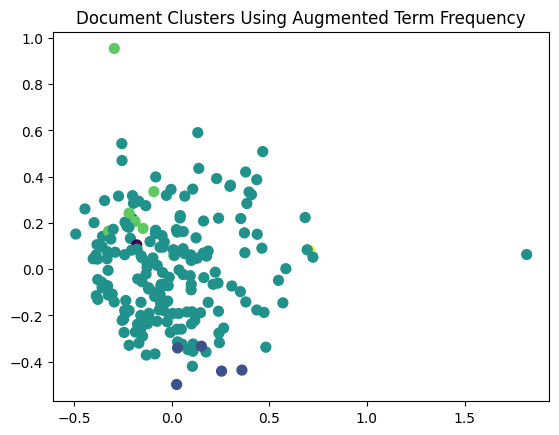

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply K-Means
kmeans = KMeans(n_clusters=num_topics, random_state=42)
kmeans.fit(augmented_dtm)
clusters = kmeans.labels_

# Visualize clusters in 2D
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(augmented_dtm)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='viridis', s=50)
plt.title("Document Clusters Using Augmented Term Frequency")
plt.show()


In [34]:
print(clusters)

[2 2 2 2 4 2 1 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 3 3 2 2 2 2 2 2 2 2 2 2 1 3 2 2 2 2 2 1 2 2 2 2 2 2 2 2 3
 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2]


In [35]:
# I believe the performance got worse: from augmented_dtm_df.head() we can see lots of unrelevant terms added to the 
#dataframe and also the clustering shape changes in a way that most of documents are now belong to topic 2 and all the datapoints
# are really close to each other and the groups are not well separated